<a href="https://colab.research.google.com/github/rubusarbaro/supplychain-forecast-FIME/blob/main/PIA_Prophet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
##################################################
##                                              ##
##             PRODUCTO INTEGRADOR              ##
##    Pronósticos en la Cadena de Suministro    ##
##                                              ##
##  Método: Prophet                             ##
##                                              ##
##  Saúl Roberto Morales Velázquez              ##
##  1856691                                     ##
##                                              ##
##################################################

#**Librerías**

In [70]:
### Librerías de Google para uso en Colab.
from google.colab import files, userdata  # Permite utilizar los datos de usuario.

### Librerías para trabajar con los datos
import json # Permite trabajar con datos en formato JSON.
import numpy as np # Permite trabajar con opercaciones matemáticas avanzadas.
import pandas as pd # Permite trabajar con data frames.
import requests
from sklearn.metrics import mean_absolute_percentage_error as MAPE # Métricas de evaluación.

### Librerías para generar gráficas
from prophet.plot import plot_plotly, plot_components_plotly  # Generador de gráficas de componentes de Meta Prophet.
import plotly.express as px # Librería que permite la creación de gráficas interactivas.
import plotly.graph_objects as go # Librería que permite la creación de gráficas interactivas.

### Librería del modelo a utilizar
from prophet import Prophet # Prophet de Meta (Facebook)

#**Funciones**

In [2]:
def seasonality_check(df: object, ds_name: str) :
  """
    Identifica la periodicidad de los datos en un DataFrame.

    Args:
        df (object): DataFrame que contiene los datos a analizar.
        ds_name (str): Nombre de la columna que contiene las fechas.

    Returns:
        dict: Diccionario con los parámetros booleanos de periodicidad.
  """

  # Parámetros por defecto
  day = False
  week = True
  month = True
  year = True

  # Revisa cuántos periodos contiene el dataframe.
  periods = min (
      (max(df[ds_name]) - min(df[ds_name])).days,
      df.shape[0]
  )

  if periods == 1 :
    day = True
  if periods < 7 :
    week = False
  if periods < 90 : # El rango de 90 días parece ser sugerido por el profesor.
    month = False
  if periods <= 365 :
    year = False

  dictionary = {  # Diccionario de valores booleanos con los parámetros.
      "day" : day,
      "week" : week,
      "month" : month,
      "year" : year
  }

  return dictionary

In [3]:
def real_plt(df: object, time_column_name: str, value_column_name: str, title: str, xaxis_title="Tiempo", yaxis_title="Ventas") :
  """
  Grafica la serie de tiempo con los datos reales.

  Args:
      df (object): DataFrame que contiene los datos a graficar.
      time_column_name (str): Nombre de la columna que contiene las fechas.
      value_column_name (str): Nombre de la columna que contiene los valores.
      title (str): Título de la gráfica.

  Returns:
      Object: Gráfica de la serie de tiempo.
  """

  fig = px.line(df, x=time_column_name, y=value_column_name, title=title)

  fig.update_xaxes(
    rangeslider_visible=True,
    rangeselector=dict(
      buttons=list([
        dict(count=1, label="1m", step="month", stepmode="backward"),
        dict(count=6, label="6m", step="month", stepmode="backward"),
        dict(count=1, label="YTD", step="year", stepmode="todate"),
        dict(count=1, label="1y", step="year", stepmode="backward"),
        dict(step="all")
      ])
    )
  )

  fig.update_layout(
    title = title,
    xaxis_title = "Tiempo",
    yaxis_title = "Tipo de cambio"
  )

  return fig.show()

In [67]:
def real_vs_forecast_plt(real_df: object, real_time_column_name: str, real_value_column_name: str, forecast_df: object, title: str, forecast_time_column_name = "ds", forecast_value_column_name = "yhat", xaxis_title = "Tiempo", yaxis_title = "Ventas") :
  """
  Grafica la comparativa de las series de tiempo con los datos reales y pronosticados.

  Args:
      real_df (object): DataFrame que contiene los datos reales.
      real_time_column_name (str): Nombre de la columna que contiene las fechas de los datos reales.
      real_value_column_name (str): Nombre de la columna que contiene los valores reales.
      forecast_df (object): DataFrame que contiene los datos pronosticados.
      title (str): Título de la gráfica.
      forecast_time_column_name (str): Nombre de la columna que contiene las fechas de los datos pronosticados.
      forecast_value_column_name (str): Nombre de la columna que contiene los valores pronosticados.

  Returns:
      Object: Gráfica de la serie de tiempo.
  """

  fig = go.Figure()

  fig.add_trace(
      go.Scatter(
          x = forecast_df[forecast_time_column_name],
          y = forecast_df[forecast_value_column_name],
          name = "Prophet",
          line = dict(color = "#8C000F", width = 3, dash = "dash")
      )
  )

  fig.add_trace(
      go.Scatter(
          x = real_df[real_time_column_name],
          y = real_df[real_value_column_name],
          name = "Real",
          line = dict(color = "olive", width = 3, dash = "dash")
      )
  )

  fig.update_layout(title = title, xaxis_title=xaxis_title, yaxis_title=yaxis_title)

  return fig.show()

In [6]:
def difference_df(df: object, data_column_name: str) :
  """
  Permite obtener la diferencia entre cada fila de datos en elo data frame.

  Args:
      df (object): DataFrame.
      data_column_name (str): Nombre de la columna que contiene los valores.

  Returns:
      Object: DataFrame con la diferencia entre cada fila.
  """

  df_diff = df
  df_diff["diff"] = np.nan

  past_number = 0
  for index, row in df.iterrows():
    if index == 0:
      df_diff.at[index, "diff"] = 0
      past_number = row[data_column_name]
    else:
      df_diff.at[index, "diff"] = (float(row[data_column_name]) / float(past_number))-1
      past_number = row[data_column_name]

  return df

In [40]:
def get_spike_dates(df: object, date_column_name: str, difference_column_name="diff") :
  """
  Obtiene los outliers o fechas de la serie de tiempo con una variación significativa.

  Args:
      df (object): DataFrame.
      date_column_name (str): Nombre de la columna que contiene las fechas.
      difference_column_name (str): Nombre de la columna que contiene las diferencias.

  Returns:
      List: Lista con las fechas de los outliers.
  """

  ### Varibles de trabajo
  avg_diff = np.mean(abs(df[difference_column_name])) # Diferencia promedio absoluta.
  std_diff = np.std(abs(df[difference_column_name]))  # Desviación estándar del conjunto de datos.
  dates = []  # Lista donde se almacenan las fechas de outliers.

  for index, row in df.iterrows():  # Iteración por cada file del conjunto de datos.
    if abs(row[difference_column_name]) > avg_diff + 3*std_diff:  # Si el valor absoluto de la fila es mayor a la diferencia promedio + 3 veces la desviación estándar (fórmula comunmente empleada para detección de outliers).
      dates.append(row[date_column_name]) # Si se cumple el criterio, añade la fecha a la lista de fechas.

  return dates  # Retorna la lista de fechas.

#**Clases**

In [41]:
class banxico() :
  """
  Clase que permite trabajar con los datos abiertos obtenidos mediante la API de Banxico.

  Args:
      token (str): Token de Banxico.
  """
  def __init__(self, token: str) :
    self.token = token  # Token de la API de Banxico.
    self.serie_ID = "The serie ID hasn't been defined yet."  # Última serie de datos utilizada en el modelo.
    self.url = "The serie ID hasn't been defined yet." # URL con la última serie de datos utilizada en el modelo.
    self.response = "The serie ID hasn't been defined yet."  # Respuesta HTTP de la última petición.
    self.HTTP_status_code = 0 # Código de estatus HTTP de la última petición.
    self.HTTP_status = "The serie ID hasn't been defined yet." # Estatus HTTP legible por humanos de la última petición.
    self.json_data = "The serie ID hasn't been defined yet."  # Datos en formato JSON utilizados para la construcción del conjunto de datos.
    self.title = "The serie ID hasn't been defined yet."  # Título del conjunto de datos, obtenido de la petición HTTP original.
    self.df = pd.DataFrame()  # Conjunto de datos.

  def get_df(self, serie_ID: str) :
    """
    Obtiene los datos de la serie de Banxico en formato de conjunto de datos (data frame).

    Args:
        serie_ID (str): ID de la serie de datos.

    Returns:
        Object: Conjunto de datos.
    """

    import requests # Permite realizar peticiones HTML.
    HTTP_codes = {
      "200" : "OK",
      "400" : "Bad Request",
      "401" : "Unauthorized",
      "403" : "Forbidden",
      "404" : "Not Found",
      "500" : "Internal Server Error",
    } # Diccionario de estatus HTTP.

    self.url = f"https://www.banxico.org.mx/SieAPIRest/service/v1/series/{serie_ID}/datos?token={self.token}" # Construye la URL del API para la serie de datos y la almacena en la variable del objeto.

    self.response = requests.get(self.url)  # Petición HTML.
    self.HTTP_status_code = self.response.status_code # Almacena el código de la petición HTML.
    self.HTTP_status = HTTP_codes[str(self.HTTP_status_code)] # Almacena el significado del código HTML.

    self.json_data = self.response.json() # Petición en formato JSON.
    self.title = self.json_data["bmx"]["series"][0]["titulo"] # Extrae el título de la serie de datos del JSON y la almacena en una variable del objeto.
    self.df = pd.DataFrame(self.json_data["bmx"]["series"][0]["datos"]) # Extrae los datos del JSON y los almacena en un conjunto de datos.
    self.df["fecha"] = pd.to_datetime(self.df["fecha"], format="%d/%m/%Y")  # Convierte las fechas en formato STR en formato datetime.

    if self.HTTP_status_code == 200 : # Revisa si la petición es correcta.
      return self.df  # Si es correcta, retorna el conjunto de datos.
    else :  # De lo contrario…
      print(f"Ha ocurrido un error: ({self.HTTP_status_code}) {self.HTTP_status}")  # Imprime el código de error
      return None # Y no retorna nada

#**Conjunto de datos**

In [58]:
# @title Conjunto de datos
Fuente = "Banxico" # @param ["Banxico"]
Datos = "Tipo de cambio MXN/USD" # @param ["Tipo de cambio MXN/USD"]

series_dict = {
    "Tipo de cambio MXN/USD" : "SF43718"
}

banxico_serieID = series_dict[Datos]

data = banxico(userdata.get('Banxico_Token'))
df = data.get_df(banxico_serieID)
df.head()

,fecha,dato
0,1991-11-12,3.0735
1,1991-11-13,3.0712
2,1991-11-14,3.0718
3,1991-11-15,3.0684
4,1991-11-18,3.0673


In [60]:
real_plt(df, "fecha", "dato", data.title, yaxis_title="Tipo de cambio")

#**Prophet**

In [66]:
# @title Parámetros del modelo
Días_a_predecir = 90 # @param {type:"slider", min:1, max:90, step:1}
Crecimiento = "linear" # @param ["linear","logistic"]
Modo_de_estacionanilidad = "additive" # @param ["additive","multiplicative"]
Intérvalo_de_búsqueda_de_cambios = 0.95 # @param {type:"slider", min:0, max:1, step:0.01}
Intérvalo_de_confianza = 0.95 # @param {type:"slider", min:0, max:1, step:0.01}
Flexibilidad_estacional = 5.00 # @param {type:"slider", min:0, max:10, step:0.01}
Sensibilidad_ante_cambios = 0.05 # @param {type:"slider", min:0, max:10, step:0.01}

days2forecast = Días_a_predecir
Prophet_growth = Crecimiento
Prophet_seasonality_mode = Modo_de_estacionanilidad
Prophet_changepoint_range = Intérvalo_de_búsqueda_de_cambios
Prophet_interval_width = Intérvalo_de_confianza
Prophet_seasonality_prior_scale = Flexibilidad_estacional
Prophet_changepoint_prior_scale = Sensibilidad_ante_cambios

dictionary_seasonality = seasonality_check(df = df, ds_name = "fecha") # Revisa la periodicidad del dataframe.

ph_parameters = { # Genera diccionado con los parámetros utilizados por Prophet.
    "growth" : Prophet_growth,
    "changepoint_range" : Prophet_changepoint_range,
    "interval_width" : Prophet_interval_width,

    "daily_seasonality" : dictionary_seasonality["day"],
    "weekly_seasonality" : dictionary_seasonality["week"],
    # "monthly_seasonality" : dictionary_seasonality["month"],  # Parece que Prophet no requiere este parámetro.
    "yearly_seasonality" : dictionary_seasonality["year"],

    "seasonality_mode" : Prophet_seasonality_mode,
    "seasonality_prior_scale" : Prophet_seasonality_prior_scale,
    # "holidays_prior_scale" : 1, # No estoy usando «vacaciones».
    "changepoint_prior_scale" : Prophet_changepoint_prior_scale
}

dictionary_seasonality  # Muestra cuales son los parámetros de temporalidad que determinó el algoritmo.

{'day': False, 'week': True, 'month': True, 'year': True}

#**Entrenamiento del modelo**

In [61]:
data_model = df.rename(columns={"fecha": "ds", "dato": "y"})  # Cambia el nombre de las columnas por aquellas que requiere Prophet para trabajar y crea un nuevo data frame con el nombre de estas columnas.

model = Prophet(**ph_parameters) # Crea un modelo de Prophet con los parámetros establecidos.
# model.add_seasonality(name='monthly', period=30.5, fourier_order=5) # Agrega temporalidad mensual al modelo.
model.fit(data_model) # Agrega los datos al modelo de Prophet.

future_dates = model.make_future_dataframe(periods=days2forecast, freq="d")  # Establece los parámetros para un pronóstico a 90 días (en este caso se colocan mediante el slider al inicio de la libreta).
forecast = model.predict(future_dates)  # Crea el propóstico.

DEBUG:cmdstanpy:input tempfile: /tmp/tmpwgus14yo/fzg8v7qt.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpwgus14yo/gb7fmyrc.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=12045', 'data', 'file=/tmp/tmpwgus14yo/fzg8v7qt.json', 'init=/tmp/tmpwgus14yo/gb7fmyrc.json', 'output', 'file=/tmp/tmpwgus14yo/prophet_modele5lel4x8/prophet_model-20250330001218.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
00:12:18 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
00:12:22 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [68]:
real_vs_forecast_plt(real_df = df, real_time_column_name = "fecha", real_value_column_name = "dato", forecast_df = forecast, title="Tipo de cambio real vs Prophet",yaxis_title = "Tipo de cambio")  # Crea la gráfica comparativa de las ventas reales vs el pronóstico.
# model.plot(forecast)  # Crea la gráfica del forecast.
# plt.show()  # Muestra la gráfica del forecast.

#**Componentes**

In [69]:
forecast['ds'] = pd.to_datetime(forecast['ds']) # Asegura que las fechas en el forecast se muestren el formato ISO.

fig_comparative = plot_plotly(model, forecast)  # Gráfica d serie de tiempo combinada.

fig_comparative.update_layout(
  title = "Ventas reales vs Prophet",
  xaxis_title = "Tiempo",
  yaxis_title = "Tipo de cambio"
)

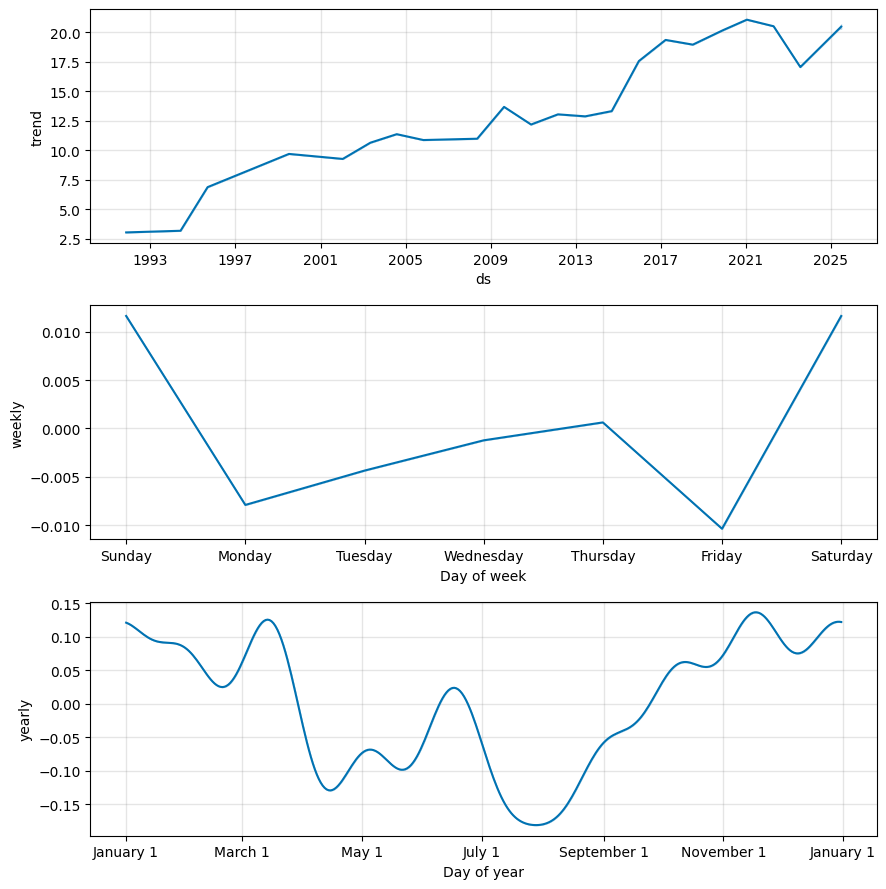

In [64]:
fig_components = model.plot_components(forecast); # Gráfica de componentes. Uso un punto y coma (;) para que solo se muestre la gráfica una vez.

#**MAPE**

In [65]:
mape_value = MAPE(data_model["y"], forecast.iloc[:-days2forecast]["yhat"]) * 100 # Función mean_absolute_percentage_error (MAPE) de sklearn
mape_value

3.288889800761753

#**Descarga de datos**

In [51]:
forecast.to_csv("forecast.csv")
files.download("forecast.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>